# Black-box optimisation capstone

Eight unknown functions. Each week I submit one input per function and get one number
back. The job is to find the input that gives the highest output for each one.

This notebook runs the whole thing end to end. It loads the data I have collected so far,
rebuilds the models, runs the check I use to decide how cautious to be each week, and
redraws the results. At the end it regenerates my most recent set of queries and compares
them against the file I actually submitted.

Run it top to bottom. It needs numpy, scipy, scikit-learn and matplotlib, all listed in
`requirements.txt`. The whole notebook takes two or three minutes. Sections 3 and 6 are the slow parts,
because each refits a model once per data point.

In [1]:
# Standard imports, plus the bits of scikit-learn that do the modelling.
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.exceptions import ConvergenceWarning

# The fitting routine warns whenever a length scale settles near the edge of its allowed
# range. That happens a lot here and it is expected, not a fault: several inputs genuinely
# do nothing, so the model pushes their length scale to the top of the range to ignore
# them. Hiding the warnings just keeps the output readable.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# The data lives at the top of the repo, so if this notebook is opened from the
# notebooks folder, step up one level first.
if not os.path.isdir("data") and os.path.isdir("../data"):
    os.chdir("..")
print("found the data folder:", os.path.isdir("data"))

# Fixed seed so anyone running this gets exactly the numbers below.
SEED = 0
N_CAND = 50_000

# How many inputs each function takes.
DIMS = {1: 2, 2: 2, 3: 3, 4: 4, 5: 4, 6: 5, 7: 6, 8: 8}

# Function 5's outputs span several orders of magnitude, so I model the log instead.
LOG_Y = {5}
# Function 2 is described as noisy in the brief, so its model gets a noise term.
NOISY = {2}

# How many points each function started with, before I submitted anything.
INITIAL = {1: 10, 2: 10, 3: 15, 4: 30, 5: 20, 6: 20, 7: 30, 8: 40}

found the data folder: True


## 1. The data

Every function came with a block of starting data and has grown by one point a week
since. Function 1 is the smallest at 2 inputs, Function 8 the largest at 8.

In [2]:
def load(i):
    """Read one function's inputs and outputs off disk."""
    X = np.atleast_2d(np.load(f"data/function_{i}/inputs.npy"))
    y = np.ravel(np.load(f"data/function_{i}/outputs.npy"))
    return X, y

# Print a summary row per function: size, dimensions, and how far it has come.
print(f"{'':<4}{'inputs':>7}{'points':>8}{'started':>8}{'rounds':>8}"
      f"{'start best':>14}{'best now':>14}")
for i in range(1, 9):
    X, y = load(i)
    n0 = INITIAL[i]
    running = np.maximum.accumulate(y)   # best value seen up to each point
    print(f"F{i:<3}{X.shape[1]:>7}{len(y):>8}{n0:>8}{len(y) - n0:>8}"
          f"{running[n0 - 1]:>14.6g}{running[-1]:>14.6g}")

     inputs  points started  rounds    start best      best now
F1        2      20      10      10   7.71088e-16       1.98469
F2        2      20      10      10      0.611205      0.767861
F3        3      25      15      10    -0.0348353    -0.0348353
F4        4      40      30      10      -4.02554      0.631155
F5        4      30      20      10       1088.86       7215.67
F6        5      30      20      10     -0.714265     -0.241097
F7        6      40      30      10       1.36497       2.19128
F8        8      50      40      10       9.59848       9.95156


## 2. The model

One Gaussian process per function. The kernel is Matern with nu = 2.5, and it gets a
separate length scale per input so the model can work out for itself that some inputs
matter more than others.

I used Matern rather than the squared exponential kernel because the squared exponential
assumes a very smooth surface, and I had no reason to believe these surfaces are smooth.
Matern 5/2 is the gentler assumption.

Two functions are handled differently:

- **Function 2** is described as noisy, so its kernel includes a white noise term.
- **Function 5** ranges from about 1,000 to over 7,000, so I fit the model to the log of
  the output rather than the output itself.

In [3]:
def make_gp(i, d):
    """Build the model for function i, which takes d inputs."""
    # The constant term lets the model scale itself; Matern handles the shape.
    # length_scale=np.ones(d) gives one length scale per input, each fitted separately.
    k = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e2), nu=2.5)
    if i in NOISY:
        k = k + WhiteKernel(1e-2, (1e-6, 1e0))
    return GaussianProcessRegressor(
        kernel=k,
        normalize_y=True,           # centres the outputs so the fit is better behaved
        n_restarts_optimizer=10,    # try the fit ten times over, keep the best one
        random_state=SEED)


def fwd(i, y):
    """Put the outputs on the scale the model is fitted on."""
    return np.log(y) if i in LOG_Y else y

## 3. Deciding how much to trust each model

For the first round I chose between exploring and exploiting by eye, which was not a good
enough reason. So I replaced it with a measurement.

For each function I drop one reading, refit on everything else, and predict the reading I
dropped. I do that for every reading in turn and take the root mean squared error. Then I
compare it against the error I would get from just predicting the average of the points I
kept.

If the model beats the average, I trust it and use Expected Improvement, which exploits.
If it does not beat the average, the model is not adding anything, so I use Upper
Confidence Bound instead and explore more.

Function 1 is in the table below for completeness, but from round 8 onwards I stopped
using the model to choose its query at all. Section 6 explains what I do instead.

This cell refits a model once per data point, so it is the slow one. It takes about a
minute.

In [4]:
def loo_trust(i, X, y):
    """Leave one out: how well does the model predict a point it has not seen?

    Returns the model's error and the error from simply predicting the mean.
    Lower is better, so the model is worth using when the first number is smaller.
    """
    n = len(y)
    model_err, mean_err = [], []
    for j in range(n):
        keep = np.ones(n, bool)
        keep[j] = False                       # hide point j
        g = make_gp(i, X.shape[1]).fit(X[keep], fwd(i, y[keep]))
        model_err.append((g.predict(X[j:j + 1])[0] - fwd(i, y[j])) ** 2)
        mean_err.append((fwd(i, y[keep]).mean() - fwd(i, y[j])) ** 2)
    return np.sqrt(np.mean(model_err)), np.sqrt(np.mean(mean_err))


trust_table = {}
print(f"{'':<4}{'model error':>13}{'mean error':>13}  verdict")
for i in range(1, 9):
    X, y = load(i)
    g_rmse, m_rmse = loo_trust(i, X, y)
    trust_table[i] = (g_rmse, m_rmse)
    verdict = "trust it, use EI" if g_rmse < m_rmse else "do not trust it, use UCB"
    print(f"F{i:<3}{g_rmse:>13.3f}{m_rmse:>13.3f}  {verdict}")

      model error   mean error  verdict


F1          0.410        0.690  trust it, use EI


F2          0.218        0.282  trust it, use EI


F3          0.076        0.074  do not trust it, use UCB


F4          4.585        9.367  trust it, use EI


F5          1.993        2.538  trust it, use EI


F6          0.255        0.625  trust it, use EI


F7          0.322        0.596  trust it, use EI


F8          0.049        1.207  trust it, use EI


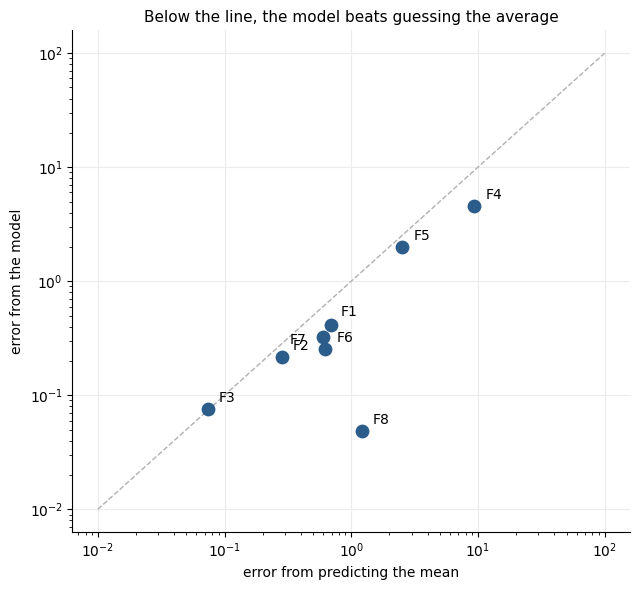

In [5]:
# The same numbers as a chart. Anything below the dashed line is a model worth using.
fig, ax = plt.subplots(figsize=(6.5, 6))

# F1 and F7 land almost on top of each other, so their labels need nudging apart.
nudge = {1: (7, 7), 7: (-24, -5)}

for i, (g, m) in trust_table.items():
    ax.scatter(m, g, s=80, color="#2b5c8a", zorder=3)
    ax.annotate(f"F{i}", (m, g), xytext=nudge.get(i, (8, 5)),
                textcoords="offset points", fontsize=10)

ax.plot([1e-2, 1e2], [1e-2, 1e2], color="#b0b0b0", linestyle="--", linewidth=1, zorder=1)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("error from predicting the mean")
ax.set_ylabel("error from the model")
ax.set_title("Below the line, the model beats guessing the average", fontsize=11)
ax.grid(True, color="#ececec", linewidth=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Progress so far

Best value found so far, round by round. Round 0 is the starting data, before I had
submitted anything.

These are eight separate panels rather than one chart because the scales are nothing like
each other. Function 5 reaches about 7,000 while Function 1 started near 1e-16, so sharing
an axis would flatten everything except Function 5.

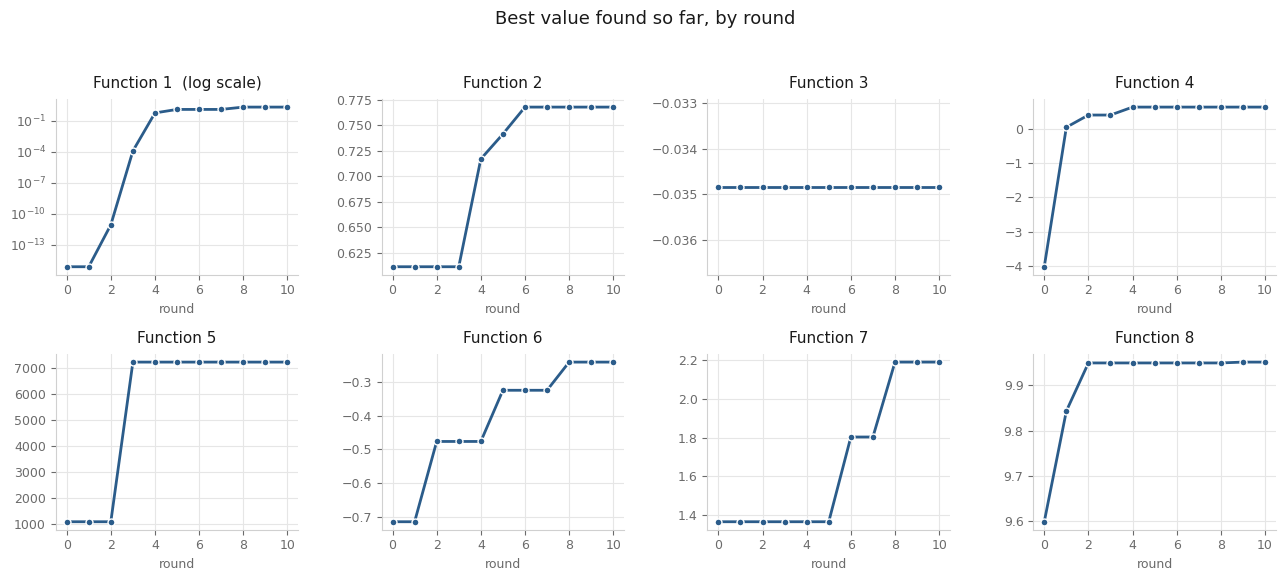

In [6]:
INK, MUTED, LINE = "#1a1a1a", "#6b6b6b", "#2b5c8a"

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
for i, ax in enumerate(axes.flat, start=1):
    _, y = load(i)
    n0 = INITIAL[i]
    running = np.maximum.accumulate(y)
    rounds = np.arange(0, len(y) - n0 + 1)
    series = np.concatenate([[running[n0 - 1]], running[n0:]])

    ax.plot(rounds, series, color=LINE, linewidth=2, marker="o", markersize=5,
            markerfacecolor=LINE, markeredgecolor="white")
    ax.set_title(f"Function {i}", fontsize=11, color=INK, pad=8)
    ax.tick_params(colors=MUTED, labelsize=9)
    ax.grid(True, color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#d0d0d0")
    # Function 1 crossed about fifteen orders of magnitude, so it needs a log axis.
    if i == 1:
        ax.set_yscale("log")
        ax.set_title("Function 1  (log scale)", fontsize=11, color=INK, pad=8)
    ax.set_xlabel("round", fontsize=9, color=MUTED)

fig.suptitle("Best value found so far, by round", fontsize=13, color=INK, y=0.98)
fig.tight_layout(rect=[0, 0.02, 1, 0.95])
plt.show()

## 5. Best result for each function

The input that produced the highest output so far, per function.

In [7]:
for i in range(1, 9):
    X, y = load(i)
    j = int(np.argmax(y))                       # position of the best reading
    coords = ", ".join(f"{v:.6f}" for v in X[j])
    print(f"F{i}  best output {y[j]:>14.6g}   at  {coords}")

F1  best output        1.98469   at  0.629435, 0.630089
F2  best output       0.767861   at  0.677557, 0.999746
F3  best output     -0.0348353   at  0.492581, 0.611593, 0.340176
F4  best output       0.631155   at  0.346904, 0.417703, 0.361887, 0.423607
F5  best output        7215.67   at  0.977327, 0.975696, 0.997961, 0.967811
F6  best output      -0.241097   at  0.493927, 0.393097, 0.642944, 0.687384, 0.216892
F7  best output        2.19128   at  0.192799, 0.332702, 0.206571, 0.161466, 0.325191, 0.699612
F8  best output        9.95156   at  0.038549, 0.143896, 0.165282, 0.153910, 0.719373, 0.548830, 0.157002, 0.073061


## 6. Reproducing my last submission

This rebuilds the queries I sent for round 8 and checks them against the file I actually
submitted. Nothing is overwritten.

To do it honestly the data has to be rolled back by one reading per function. The most
recent reading in each file is the week 8 result, and that only arrived days after I had
already chosen and sent those queries, so the model must be fitted without it. The
leave-one-out check is rerun on the rolled-back data as well, because that is what decided
Expected Improvement or Upper Confidence Bound at the time.

Functions 2 to 8 go through the model and the trust check above. Function 1 is handled
separately, and it is worth saying why.

Function 1's output falls away from its peak faster than anything else here. In round 7 I
had a good point, probed 0.03 to one side of it, and found that cost almost nothing. So I
assumed the surface was symmetric and stepped 0.12 the other way. The value fell from 1.18
to 2.2e-13, which is thirteen orders of magnitude for one step. That was an extrapolation
past everything I had measured, and it was a bad idea.

From round 8 on I fit a curve through the three readings I already hold across that axis
and take the peak of that curve, which sits between points I have measured rather than
beyond them.

In [8]:
def load_at_round_8(i):
    """The data as it stood when I chose round 8: the starting readings plus rounds 1 to 7.
    Cut by count rather than "drop the newest", so it stays right as later rounds are added."""
    X, y = load(i)
    n = INITIAL[i] + 7
    return X[:n], y[:n]

queries = {}

# --- Function 1: interpolate between the three readings I already hold ---
best_point = np.array([0.617938, 0.638734])
P0 = np.array([0.577271, 0.584651])
P1 = np.array([0.650114, 0.681526])
u = (P1 - P0) / np.linalg.norm(P1 - P0)     # direction along the ridge
perp = np.array([-u[1], u[0]])              # the sideways direction across it

# The three readings taken across that sideways axis, as offsets from the best point.
obs = [(-0.03, 1.1142113638492601),
       (0.00, 1.1838076163353304),
       (0.12, 2.2128269235845376e-13)]
offsets = np.array([o[0] for o in obs])
log_vals = np.log10([abs(o[1]) for o in obs])

# A parabola through those three points. Its peak is the best guess at where the ridge is.
c = np.polyfit(offsets, log_vals, 2)
peak_offset = -c[1] / (2 * c[0])
queries[1] = best_point + peak_offset * perp
print(f"F1   curve peaks at offset {peak_offset:+.4f}, which sits between readings I hold")

# --- Functions 2 to 8: fit, check, then the matching acquisition function ---
rng = np.random.default_rng(SEED)
for i in range(2, 9):
    d = DIMS[i]
    X, y = load_at_round_8(i)
    yt = fwd(i, y)
    # Rerun the check on the rolled-back data. The section 3 table is today's view and
    # includes a reading I did not have when this query was chosen.
    g_rmse, m_rmse = loo_trust(i, X, y)
    trust = g_rmse < m_rmse

    gp = make_gp(i, d).fit(X, yt)
    cand = rng.random((N_CAND, d))           # 50,000 random points to score
    mu, sd = gp.predict(cand, return_std=True)
    sd = np.maximum(sd, 1e-12)

    if trust:
        # Expected Improvement: how much better than the current best we expect to do.
        z = (mu - yt.max()) / sd
        acq = (mu - yt.max()) * norm.cdf(z) + sd * norm.pdf(z)
    else:
        # Upper Confidence Bound: favour points the model is least sure about.
        acq = mu + 2.0 * sd

    j = int(np.argmax(acq))
    queries[i] = cand[j]
    print(f"F{i}   {'EI ' if trust else 'UCB'}  "
          f"{'exploration' if sd[j] > np.median(sd) else 'exploitation'}")

F1   curve peaks at offset -0.0144, which sits between readings I hold


F2   EI   exploitation


F3   UCB  exploration


F4   EI   exploitation


F5   EI   exploration


F6   EI   exploitation


F7   EI   exploitation


F8   EI   exploitation


In [9]:
# Format them the way the portal wants, then compare against the file I sent.
lines = [f"Function {i}: " + "-".join(f"{v:.6f}" for v in queries[i]) for i in range(1, 9)]
regenerated = "\n".join(lines)
print(regenerated)

with open("submissions/round8_module19.txt") as f:
    submitted = f.read().strip()

print()
print("matches the file I submitted:", regenerated == submitted)

Function 1: 0.629435-0.630089
Function 2: 0.678440-0.001408
Function 3: 0.198746-0.205708-0.305489
Function 4: 0.027108-0.408480-0.419992-0.511708
Function 5: 0.847467-0.082741-0.987905-0.999755
Function 6: 0.493927-0.393097-0.642944-0.687384-0.216892
Function 7: 0.192799-0.332702-0.206571-0.161466-0.325191-0.699612
Function 8: 0.003358-0.131442-0.141821-0.006481-0.748614-0.371739-0.212030-0.892288

matches the file I submitted: True


## 7. What this run taught me

**Function 3 has not moved in eight rounds.** Not one query has beaten the starting data.
The leave-one-out check fails on it nearly every week, so I have been exploring rather than
exploiting, and none of it has landed. I do not have a good answer for this one.

**Function 4 got harder as it got more data.** Its leave-one-out error rose while the
dataset grew from 31 points to 38, and in week 8 it returned -8.85, its worst reading yet,
after passing the trust check. More data normally helps. When it makes the model worse
instead, the problem is the model rather than the amount of information. From round 9 its
candidates are drawn from a box around its best point rather than the whole space, which is
the fix the TuRBO paper describes.

**Function 1 was both the biggest win and the worst mistake.** It reached 1.18 from
7.7e-16, then I threw it away in one round by extrapolating past my own measurements and
fell to 2.2e-13. Interpolating between held readings instead recovered it and took it to
1.98, the best reading of the run. It has now converged to the spacing of its own samples:
both axes peak at points already measured, so there is nothing left for the curve fit to
suggest.

**The trust check was worth building.** Picking between exploring and exploiting on
instinct was the weakest part of my first round. Comparing the model against a flat average
is a crude test, but it is a reason rather than a hunch, and it changed what I submitted for
several functions.